# Prophet Meta
**Equipo:** Alejandro Riveros, Manuel Carreno y Carlos Diaz

## 0. Carga de Librerias

In [1]:
# Instalacion (ejecutar solo si no estan instaladas)
# !pip install prophet pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

print('Librerias cargadas correctamente')

c:\Users\manue\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Librerias cargadas correctamente


---
## 1. Indice

1. Indice
2. Que es Prophet?
3. Como funciona Prophet?
4. Parametros
5. Implementacion en Python
6. Personalización de parametros
7. Componentes
8. Evaluacion (metricas), ventajas y desventajas
9. Conclusiones

---
## 2. Que es Prophet?

Prophet es una libreria de **codigo abierto** desarrollada por el equipo de Core Data Science de **Meta** (antes Facebook) para realizar pronosticos de series de tiempo. Fue creada por Sean J. Taylor y Ben Letham, y publicada en 2017 para Python y R.

El objetivo de Prophet es **democratizar el pronostico**: permitir que tanto expertos en estadistica como usuarios sin conocimientos avanzados puedan generar predicciones confiables con pocos pasos. Esto lo diferencia de metodos como ARIMA o SARIMA, que requieren configuracion manual compleja.

**Caracteristicas principales:**

| Caracteristica | Descripcion |
|---|---|
| Codigo abierto | Disponible en PyPI (Python) y CRAN (R) |
| Robusto | Maneja valores faltantes, cambios bruscos en la tendencia y outliers |
| Rapido | Usa Stan internamente, logrando pronosticos en pocos segundos |
| Interpretable | Cada componente tiene un significado claro, no es una caja negra |
| Facil de usar | Solo requiere columnas `ds` (fecha) e `y` (valor a predecir) |
| Escalable | Disenado para trabajar con miles de series de tiempo simultaneamente |

**Aplicaciones comunes:**

- Pronostico de ventas y demanda en e-commerce y retail.
- Analisis financiero: prediccion de ingresos, precios de acciones y tipos de cambio.
- Prediccion de trafico web y consumo de energia.
- Planificacion de campanas de marketing con festivos y eventos especiales.

---
## 3. Como funciona Prophet?

Prophet usa un **modelo aditivo descomponible**. Toma una serie de tiempo y la divide en partes que se suman para generar el pronostico final:

**y(t) = g(t) + s(t) + h(t) + ε(t)**

| Componente | Representa |
|---|---|
| g(t) | Tendencia de crecimiento |
| s(t) | Estacionalidad |
| h(t) | Efecto de los festivos |
| ε(t) | Error o ruido que el modelo no explica |

A diferencia de ARIMA, Prophet trata el pronostico como un **ajuste de curvas**, lo que le da flexibilidad, velocidad e interpretabilidad.

**Proceso del modelo:**

1. Recibe datos historicos con columnas `ds` (fecha) e `y` (valor).
2. Ajusta una curva de tendencia, detectando automaticamente los **changepoints**: puntos donde la pendiente cambia.
3. Modela la estacionalidad con series de Fourier para capturar patrones periodicos suaves.
4. Incorpora festivos y eventos especiales como variables adicionales.
5. Estima los parametros usando **Stan**, un motor de inferencia bayesiana.
6. Genera el pronostico con intervalos de incertidumbre (limite superior e inferior).

---
## 4. Parametros de Prophet

Al crear el modelo se pueden configurar distintos parametros. A continuacion se describen los principales, agrupados por categoria.

**Tendencia:**

| Parametro | Descripcion | Valor por defecto |
|---|---|---|
| `growth` | Tipo de crecimiento: `linear`, `logistic` o `flat` | `linear` |
| `n_changepoints` | Numero de puntos de cambio potenciales | 25 |
| `changepoint_range` | Proporcion del historial donde se ubican los changepoints | 0.8 |
| `changepoint_prior_scale` | Flexibilidad de la tendencia. El parametro mas impactante del modelo | 0.05 |

**Estacionalidad:**

| Parametro | Descripcion | Valor por defecto |
|---|---|---|
| `yearly_seasonality` | Estacionalidad anual | `auto` |
| `weekly_seasonality` | Estacionalidad semanal | `auto` |
| `daily_seasonality` | Estacionalidad diaria, solo para datos horarios | `auto` |
| `seasonality_mode` | Modo aditivo o multiplicativo | `additive` |
| `seasonality_prior_scale` | Flexibilidad del componente estacional | 10.0 |

**Festivos:**

| Parametro | Descripcion | Valor por defecto |
|---|---|---|
| `holidays` | DataFrame con columnas `holiday` (nombre) y `ds` (fecha) | `None` |
| `holidays_prior_scale` | Magnitud del efecto de los festivos | 10.0 |

**Incertidumbre:**

| Parametro | Descripcion | Valor por defecto |
|---|---|---|
| `interval_width` | Ancho del intervalo de confianza | 0.80 |
| `uncertainty_samples` | Muestras para estimar la incertidumbre | 1000 |
| `mcmc_samples` | Muestras MCMC para inferencia bayesiana completa. 0 usa MAP | 0 |

---
## 5. Implementación en Python 

### 📊 Descripción del Dataset
El dataset que usaremos contiene registros semanales de ventas de **45 tiendas Walmart** en Estados Unidos, con **17 variables** entre febrero de 2010 y octubre de 2012.

Algunas variables de nuestro dataset son:
- `Store` — identificador de tienda (1 a 45)
- `Date` — fecha de la semana (formato YYYY-MM-DD)
- `IsHoliday` — indica si esa semana contiene un día festivo clave
- `Dept` — departamento dentro de la tienda (81 departamentos distintos)
- `Weekly_Sales` — ventas totales de esa semana en dólares (**variable objetivo**)
- `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` — condiciones económicas y climáticas
- `Type`, `Size` — tipo y tamaño de la tienda

Para este ejemplo aplicaremos Prophet usando:
- **`ds`** → Columna `Date`
-  **`y`** → Suma de `Weekly_Sales` agregada por semanda en todas las tiendas

Esto nos da un conjunto de **143 semanas** con estacionalidad anual, con picos en dias festivos como Thanksgiving y Navidad, ideal para demostrar los componentes de prophet


In [5]:
df = pd.read_csv('data\walmart_cleaned.csv')
df = df.drop(["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"], axis=1)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\manue\AppData\Local\Temp\ipykernel_12128\352301281.py:1: SyntaxWarning: invalid escape sequence '\w'
  df = pd.read_csv('data\walmart_cleaned.csv')


,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,211.096358,8.106,3,151315
1,1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,211.096358,8.106,3,151315
2,2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,211.096358,8.106,3,151315
3,3,1,2010-02-05,0,45.0,37.44,42.31,2.572,211.096358,8.106,3,151315
4,4,1,2010-02-05,0,28.0,1085.29,42.31,2.572,211.096358,8.106,3,151315


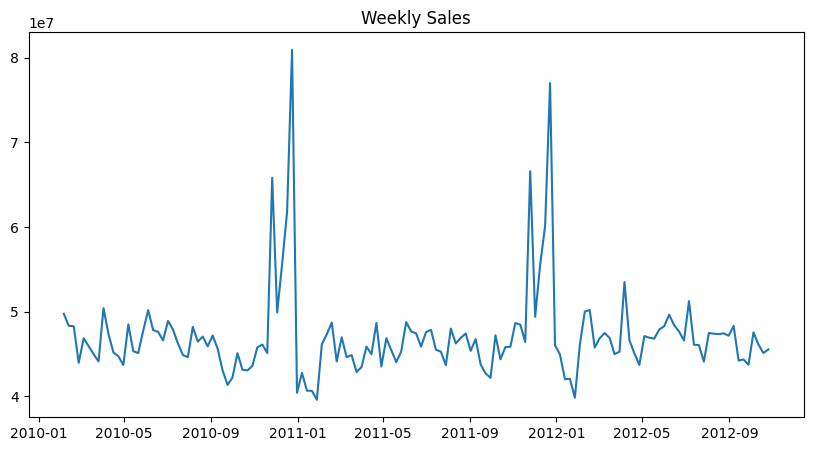

In [6]:
# Agrupamos y sumando las ventas de todas las tiendas en cada semana
df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Definimos cuales van a ser nuestro ds - y
df.columns= ["ds", "y"]
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# Visualizamos los datos antes de iniciar
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'])
plt.title("Weekly Sales")
plt.show()

In [7]:
# Verificamos datos vacios o nulos
df.duplicated()
df.isnull().sum()

ds    0
y     0
dtype: int64

## 1️⃣ Predicción de ventas futuras

20:13:34 - cmdstanpy - INFO - Chain [1] start processing
20:13:34 - cmdstanpy - INFO - Chain [1] done processing


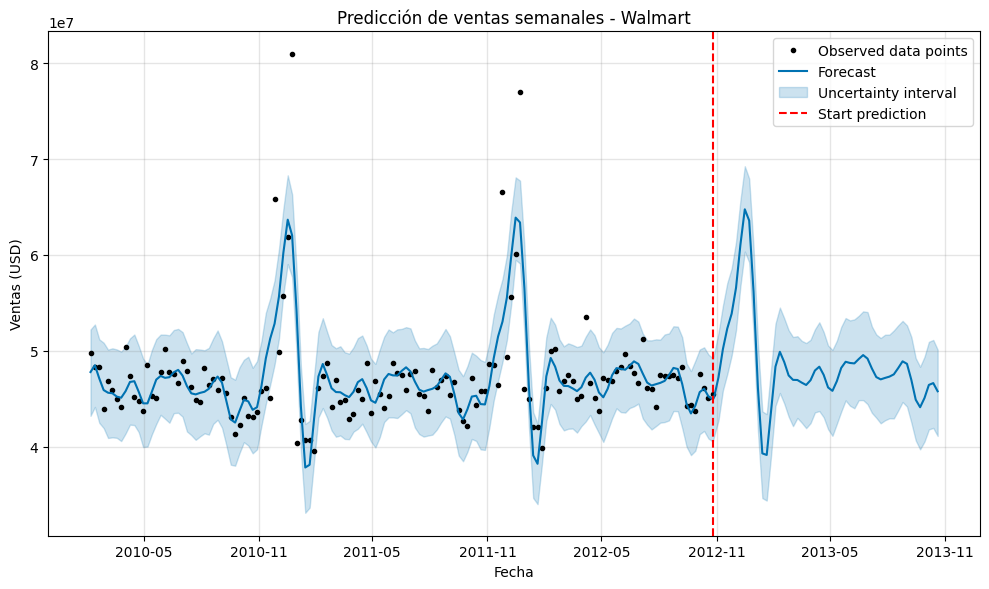

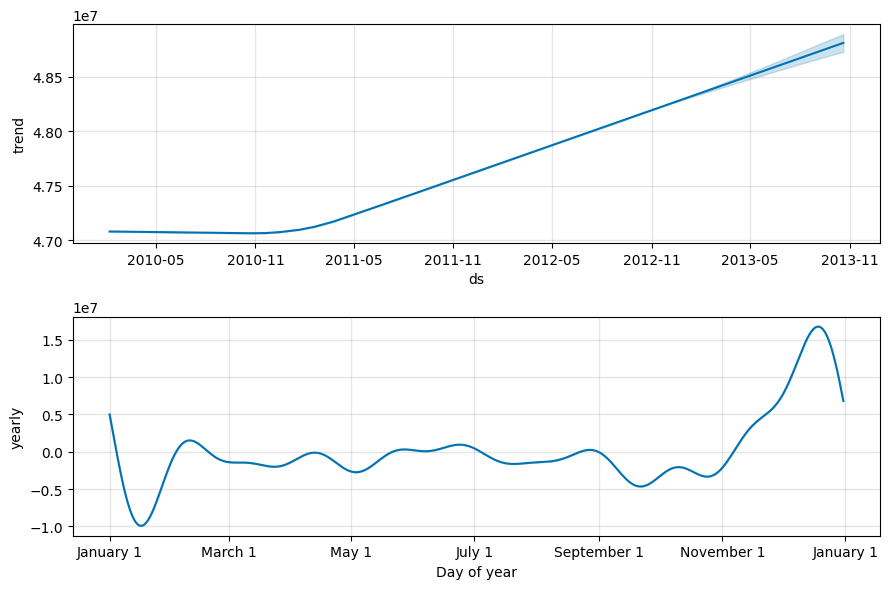

In [ ]:
# Definir el modelo 
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
modelo.fit(df)

# Crear fechas futuras (52 semanas = 1 año)
futuro = modelo.make_future_dataframe(periods=52, freq='W')
prediccion = modelo.predict(futuro)

# Gráfica de predicción
modelo.plot(prediccion)

# Linea para identificar donde inicia la predicción
fecha_corte = df['ds'].max()
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=1.5, label='Start prediction')
plt.legend()

plt.title("Predicción de ventas semanales - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()

# Gráfica de componentes 
modelo.plot_components(prediccion)
plt.tight_layout()
plt.show()

## 2️⃣ Detección de holidays

In [ ]:
#  Modelo con holidays de estados unidos 
modelo_holidays = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Agregamos automáticamente los festivos de estados unidos
modelo_holidays.add_country_holidays(country_name='US')
modelo_holidays.fit(df)

# Generar fechas futuras y predecir
futuro_h = modelo_holidays.make_future_dataframe(periods=52, freq='W')
prediccion_h = modelo_holidays.predict(futuro_h)

20:14:13 - cmdstanpy - INFO - Chain [1] start processing
20:14:13 - cmdstanpy - INFO - Chain [1] done processing


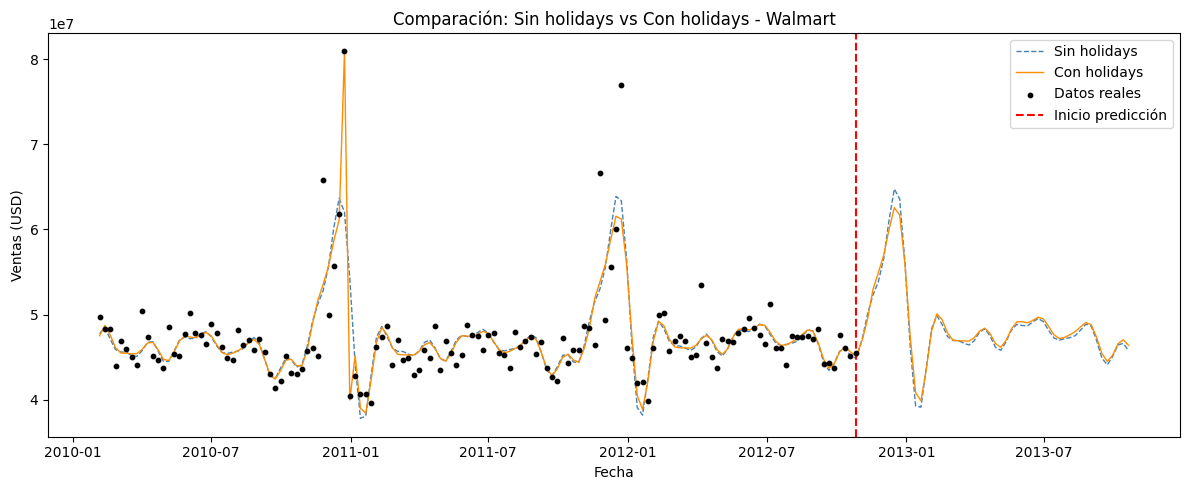

In [ ]:
# Comparar predicción sin vs con holidays 
plt.figure(figsize=(12, 5))

plt.plot(prediccion['ds'], prediccion['yhat'],
         color='steelblue', linewidth=1, label='Sin holidays', linestyle='--')

plt.plot(prediccion_h['ds'], prediccion_h['yhat'],
         color='darkorange', linewidth=1, label='Con holidays')

plt.scatter(df['ds'], df['y'],
            color='black', s=10, zorder=5, label='Datos reales')

fecha_corte = df['ds'].max()
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=1.5, label='Inicio predicción')

plt.title("Comparación: Sin holidays vs Con holidays - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ver el impacto de cada holiday en las ventas 
# Filtramos solo las semanas donde hubo un festivo reconocido por Prophet
cols_holidays = [c for c in prediccion_h.columns if 'holiday' in c.lower() or c in modelo_holidays.train_holiday_names]

impacto = prediccion_h[['ds', 'holidays']].copy()
impacto = impacto[impacto['holidays'] != 0].sort_values('holidays', ascending=False)
impacto['impacto_USD'] = impacto['holidays'].round(2)

print("=== Semanas con mayor impacto por holidays ===")
print(impacto[['ds', 'impacto_USD']].to_string(index=False))

=== Semanas con mayor impacto por holidays ===
        ds  impacto_USD
2010-12-24  20862747.15
2011-11-11   -603003.33
2012-11-11   -603003.33
2010-12-31 -13772257.62


Al usar el parametro de **add_country_holidays** hacemos que prophet agregue automaticamente los festivos de ese pais (para este caso US), el modelo logra capturar mejor los picos de ventas que el modelo base no explicaba. De esta manera, podemos identificar mejor los holidays como puede ser la semana del 24 de diciembre con un incremento de aproximadamente $20.8M (USD), esto nos confirma que Navidad es el evento más relevante en ventas para Walmart.

Por otro lado, tenemos la semana del 31 de diciembre que muestra un impacto negativo de aproximadamente $13.7M (USD), que corresponden a ventas post-navideñas (tal vez productos que no se vendieron en navidad). Ademas, En la gráfica se puede observar cómo la línea naranja se ajusta mejor a los puntos reales en las semanas de festivos, mientras que la línea azul suaviza esos picos y los subestima

## 3️⃣ Detección de anomalias

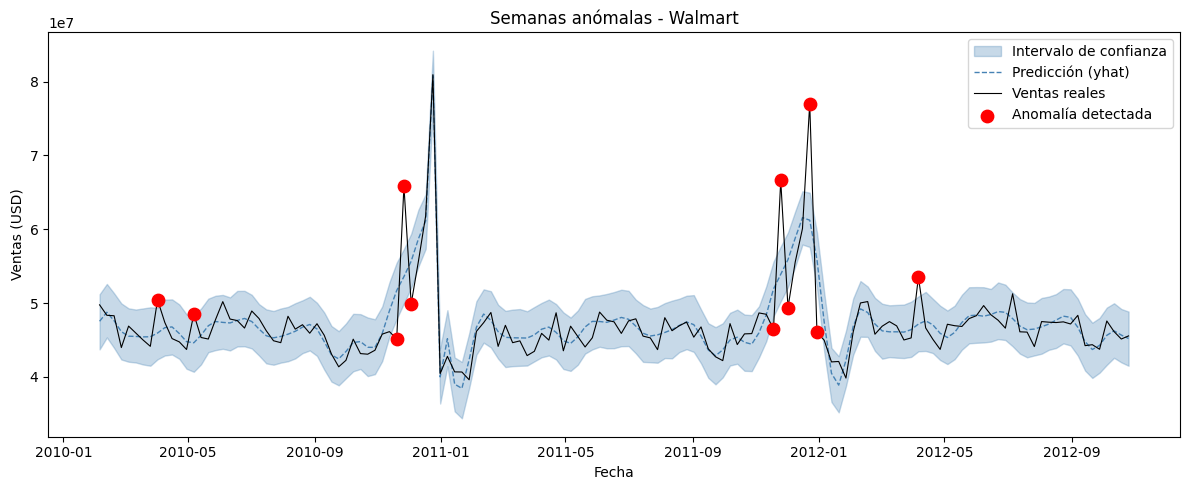

In [ ]:
# Crear df_anomalias
df_anomalias = df.merge(
    prediccion_h[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

df_anomalias['anomalia'] = (
    (df_anomalias['y'] < df_anomalias['yhat_lower'])
    |
    (df_anomalias['y'] > df_anomalias['yhat_upper'])
)

anomalias = df_anomalias[df_anomalias['anomalia']]

# Gráfica 
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df_anomalias['ds'],
                df_anomalias['yhat_lower'],
                df_anomalias['yhat_upper'],
                alpha=0.3, color='steelblue', label='Intervalo de confianza')

ax.plot(df_anomalias['ds'], df_anomalias['yhat'],
        color='steelblue', linewidth=1, linestyle='--', label='Predicción (yhat)')

ax.plot(df_anomalias['ds'], df_anomalias['y'],
        color='black', linewidth=0.8, label='Ventas reales')

ax.scatter(anomalias['ds'], anomalias['y'],
           color='red', zorder=5, s=80, label='Anomalía detectada')

plt.title("Semanas anómalas - Walmart")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
print(f"Anomalías: {len(anomalias)}")
print(anomalias['ds'].dt.strftime('%Y-%m-%d').values)

Anomalías: 11
<ArrowStringArray>
['2010-04-02', '2010-05-07', '2010-11-19', '2010-11-26', '2010-12-03',
 '2011-11-18', '2011-11-25', '2011-12-02', '2011-12-23', '2011-12-30',
 '2012-04-06']
Length: 11, dtype: str


El modelo logro detectar 11 anomalias a lo largo del tiempo de nuestro dataset, semanas donde las ventas salieron de nuestro intervalo de confianza. Los puntos rojos en la grafica nos muestran en donde hay anomalias, los puntos rojos que se encuentran por encima del intervalo son:

- **Noviembre - Diciembre de 2010 y 2011** → Se puede deber a Black Friday, Navidad y Thanksgiving
- **Abril - Mayo de 2010** → Se puede deber a la pascua y al cambio de temporada

Los puntos rojos por debajo del intervalo representan las semanas donde las ventas cayeron inesperadamente, que puede ser por posibles factores externos como el clima, cierres entre otros.

---
## 6. Personalización de parametros

Prophet permite ajustar distintos parámetros para mejorar la capacidad del modelo de capturar patrones en los datos.

---
## 7. Componentes del Modelo Prophet

### 7.1 Tendencia — g(t)

Captura el **comportamiento general a largo plazo** ignorando los altibajos del dia a dia.

**Analogia:** Es como observar el precio de una casa durante 10 anos. Puede subir en general aunque haya meses donde baje un poco.

Prophet ofrece dos tipos de tendencia:

**Tipo 1 - Lineal por tramos (el mas comun)**

Para datos sin un limite maximo. Detecta automaticamente puntos donde la tendencia cambia de velocidad. Estos se llaman **changepoints**.

**Tipo 2 - Logistico**

Para datos con un techo maximo conocido (ej: usuarios de una app en un mercado de 10 millones de personas, nunca puede superar ese numero).

> **Parametro clave:** `changepoint_prior_scale` controla la flexibilidad de la tendencia (valor por defecto = 0.05).

### 7.2 Estacionalidad — s(t)

Captura **patrones que se repiten periodicamente**.

**Analogia:** Las ventas de paraguas siempre suben en invierno. Las visitas a un sitio de noticias siempre suben los lunes. Esos son patrones estacionales.

Prophet detecta automaticamente tres tipos:

| Tipo | Cuando aplica | Ejemplo |
|---|---|---|
| **Anual** | Datos de meses o anos | Ventas navidenas, temporadas |
| **Semanal** | Datos de dias | Mas trafico los lunes que los sabados |
| **Diaria** | Datos de horas | Mas llamadas al mediodia que a las 3am |

Tambien se pueden agregar estacionalidades personalizadas con `add_seasonality()`.

### 7.3 Festivos y Eventos — h(t)

Captura **dias especiales que rompen el patron normal** y que el modelo no puede detectar por si solo.

**Analogia:** El Black Friday siempre dispara las ventas. El 25 de diciembre las visitas caen a cero. Si no le avisas al modelo, lo vera como un error extrano en los datos.

Con Prophet puedes:
- Agregar festivos de tu pais: `modelo.add_country_holidays(country_name='CO')`
- Definir eventos propios (lanzamientos, campanas de marketing)
- Especificar ventanas de impacto: cuantos dias antes y despues tambien se ven afectados

> Prophet ya tiene festivos predefinidos para Colombia, Mexico, Espana, EE.UU. y mas.

### 7.4 Codigo — Ver los componentes en accion

Usaremos el dataset clasico de Prophet: visitas diarias a la Wikipedia de **Peyton Manning** (jugador de futbol americano) de 2007 a 2016.

Este dataset es ideal porque tiene los tres componentes bien definidos:
- **Tendencia:** subio cuando era estrella de la NFL, bajo al retirarse
- **Estacionalidad anual:** mas visitas en otono/invierno (temporada NFL)
- **Estacionalidad semanal:** picos los lunes (dia despues de los partidos del domingo)

In [2]:
# ── Cargar datos ──
# Prophet necesita un DataFrame con dos columnas obligatorias:
#   ds -> fecha (formato YYYY-MM-DD)
#   y  -> valor numerico que queremos predecir

url = 'https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv'
df = pd.read_csv(url)

print(f'Registros: {len(df)}')
print(f'Desde {df["ds"].min()} hasta {df["ds"].max()}')
df.head()

Registros: 2905
Desde 2007-12-10 hasta 2016-01-20


,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


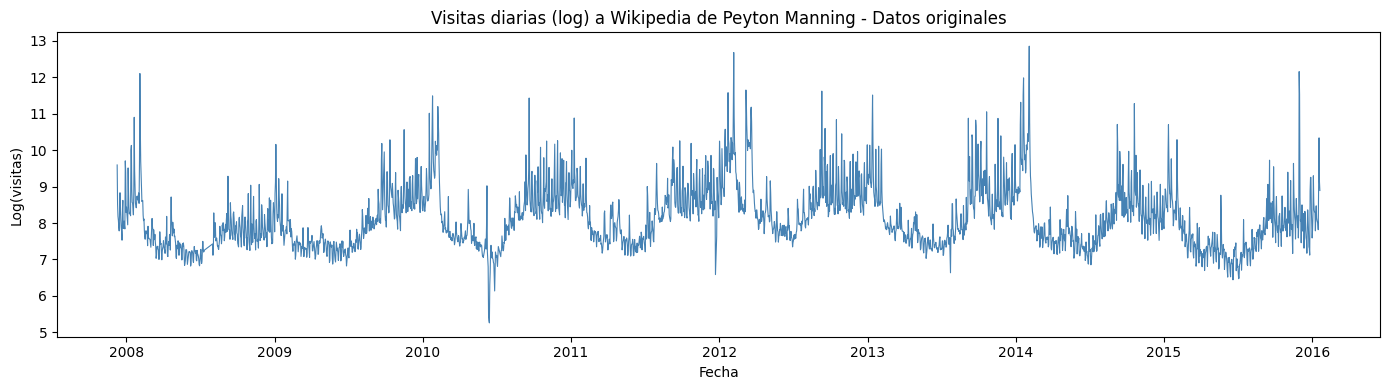

In [3]:
# ── Grafico de los datos originales ──
plt.figure(figsize=(14, 4))
plt.plot(pd.to_datetime(df['ds']), df['y'], linewidth=0.8, color='steelblue')
plt.title('Visitas diarias (log) a Wikipedia de Peyton Manning - Datos originales')
plt.xlabel('Fecha')
plt.ylabel('Log(visitas)')
plt.tight_layout()
plt.show()

In [4]:
# ── Crear y entrenar el modelo ──
modelo = Prophet(
    yearly_seasonality=True,   # detectar patrones que se repiten cada ano
    weekly_seasonality=True,   # detectar patrones que se repiten cada semana
    daily_seasonality=False    # solo aplica para datos horarios, no diarios
)

modelo.fit(df)
print('Modelo entrenado exitosamente')

14:40:28 - cmdstanpy - INFO - Chain [1] start processing


14:40:29 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado exitosamente


In [5]:
# ── Generar fechas futuras y predecir ──
# make_future_dataframe crea un DataFrame con fechas futuras
# periods=365 -> predecir 1 ano hacia adelante

futuro = modelo.make_future_dataframe(periods=365)
prediccion = modelo.predict(futuro)

# Columnas clave del resultado:
#   yhat       -> valor predicho por el modelo
#   yhat_lower -> limite inferior del intervalo de confianza
#   yhat_upper -> limite superior del intervalo de confianza
#   trend      -> componente de tendencia
#   weekly     -> componente de estacionalidad semanal
#   yearly     -> componente de estacionalidad anual

prediccion[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend', 'weekly', 'yearly']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,weekly,yearly
3265,2017-01-15,8.206966,7.489955,8.913682,7.188902,0.048296,0.969768
3266,2017-01-16,8.531961,7.721361,9.270361,7.187877,0.352285,0.991799
3267,2017-01-17,8.319378,7.552267,9.044841,7.186851,0.119640,1.012887
3268,2017-01-18,8.151994,7.375184,8.886737,7.185826,-0.066660,1.032828
3269,2017-01-19,8.163910,7.457602,8.917167,7.184801,-0.072267,1.051377


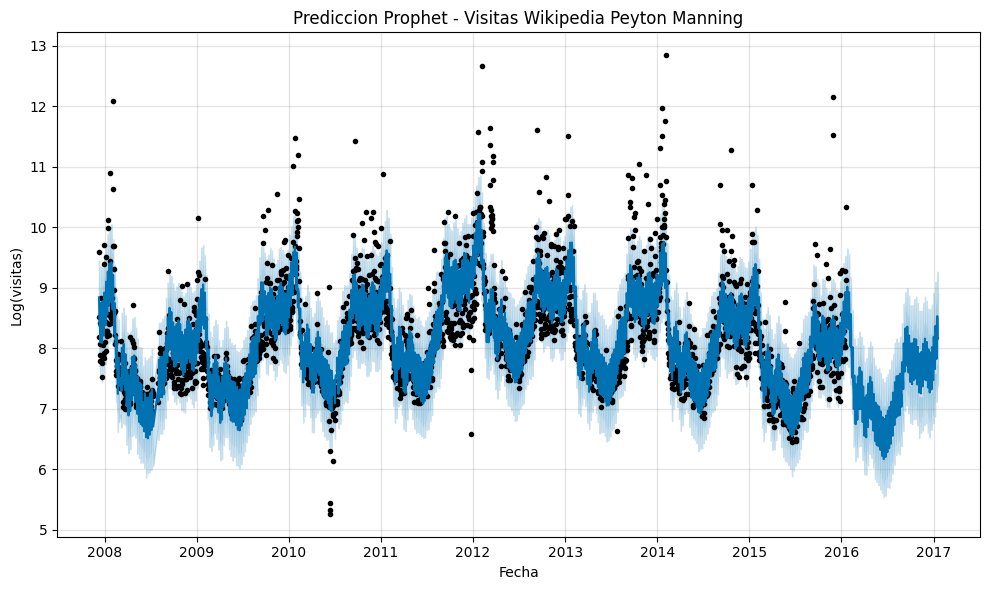

In [6]:
# ── Grafico 1: Prediccion completa ──
# Puntos negros = datos reales historicos
# Linea azul   = prediccion del modelo
# Zona celeste = intervalo de incertidumbre (el modelo no sabe el futuro con exactitud)

fig1 = modelo.plot(prediccion)
plt.title('Prediccion Prophet - Visitas Wikipedia Peyton Manning')
plt.xlabel('Fecha')
plt.ylabel('Log(visitas)')
plt.tight_layout()
plt.show()

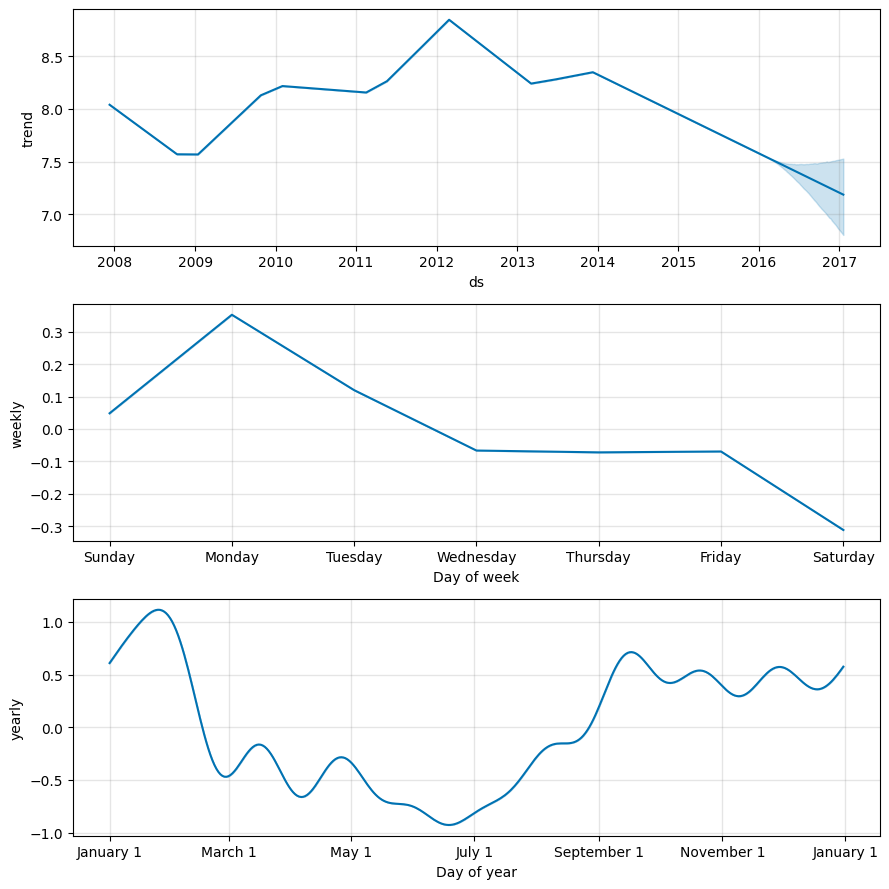

In [7]:
# ── Grafico 2: Descomposicion de componentes ──
# Este es el grafico mas util para ENTENDER por que el modelo predice lo que predice.
# Muestra por separado: tendencia, estacionalidad semanal y estacionalidad anual.

fig2 = modelo.plot_components(prediccion)
plt.tight_layout()
plt.show()

**Como leer el grafico de componentes:**

| Panel | Que muestra | Como interpretar |
|---|---|---|
| **trend** | Tendencia general | Si sube -> crecimiento a largo plazo. Si baja -> decrecimiento |
| **weekly** | Estacionalidad semanal | Que dias de la semana tienen mas actividad |
| **yearly** | Estacionalidad anual | Que meses del ano tienen mas actividad |

**Observaciones en este ejemplo:**
- La tendencia subio de 2008 a 2012 y luego bajo: coincide con la carrera de Peyton Manning
- La estacionalidad semanal muestra picos los lunes: dia despues de los partidos de la NFL
- La estacionalidad anual muestra picos en otono/invierno: temporada de la NFL

---
## 8. Evaluacion del Modelo, Ventajas y Desventajas

### 8.1 Metricas de Error

Una vez que el modelo hace predicciones, necesitamos saber **que tan buenas son**.

**Analogia:** Un modelo predice que habra 100 ventas, pero en realidad hay 90. El error es 10. Las metricas resumen todos esos errores de una manera comparable.

| Metrica | Que mide | Cuando usarla |
|---|---|---|
| **MAE** (Error Absoluto Medio) | El error promedio en las unidades de los datos | General, facil de interpretar |
| **RMSE** (Raiz del Error Cuadratico Medio) | Similar al MAE pero penaliza mas los errores grandes | Cuando los errores grandes son costosos |
| **MAPE (%)** | El error como porcentaje del valor real | Para comparar modelos en escalas distintas |
| **Coverage** | % de valores reales dentro del intervalo de confianza | Evalua la calidad de las bandas de incertidumbre |

**Referencia para el MAPE:**
```
MAPE < 10%   ->  Excelente
MAPE 10-20%  ->  Bueno
MAPE 20-50%  ->  Aceptable
MAPE > 50%   ->  Revisar el modelo
```

### 8.2 Validacion Cruzada Temporal

El metodo mas riguroso para evaluar modelos de series de tiempo.

**Que hace?** Simula el proceso de prediccion multiples veces en el pasado, como si el modelo no supiera lo que ocurrio despues de cierta fecha.

**Analogia:** Es como hacerle un examen al modelo usando episodios del pasado que ya conocemos. Si en 2014 predice correctamente lo que paso en 2015, sabemos que es confiable.

Parametros:
- **`initial`**: datos para el primer entrenamiento (ej: '730 days' = 2 anos)
- **`period`**: cada cuanto se hace un nuevo corte de evaluacion (ej: '180 days')
- **`horizon`**: que tan lejos predice en cada corte (ej: '365 days' = 1 ano)

In [8]:
# ── Validacion cruzada temporal ──
# Puede tardar unos segundos: simula multiples predicciones historicas

df_cv = cross_validation(
    modelo,
    initial='730 days',   # primeros 2 anos como entrenamiento minimo
    period='180 days',    # nuevo corte cada 6 meses
    horizon='365 days'    # evaluar predicciones a 1 ano
)

print(f'Predicciones evaluadas: {len(df_cv)}')
print(f'Columnas disponibles: {list(df_cv.columns)}')
# y=real, yhat=predicho
df_cv[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].head(8)

  0%|          | 0/11 [00:00<?, ?it/s]

14:40:31 - cmdstanpy - INFO - Chain [1] start processing


14:40:31 - cmdstanpy - INFO - Chain [1] done processing


14:40:31 - cmdstanpy - INFO - Chain [1] start processing


14:40:32 - cmdstanpy - INFO - Chain [1] done processing


...

14:40:38 - cmdstanpy - INFO - Chain [1] done processing


14:40:38 - cmdstanpy - INFO - Chain [1] start processing


14:40:39 - cmdstanpy - INFO - Chain [1] done processing


Predicciones evaluadas: 3988
Columnas disponibles: ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'y', 'cutoff']


,ds,y,yhat,yhat_lower,yhat_upper
0,2010-02-16,8.242493,8.953439,8.472068,9.445708
1,2010-02-17,8.008033,8.719766,8.222853,9.220284
2,2010-02-18,8.045268,8.603393,8.110473,9.134779
3,2010-02-19,7.928766,8.525161,8.015889,9.019640
4,2010-02-20,7.745003,8.266983,7.748964,8.758941
5,2010-02-21,7.866339,8.598089,8.096462,9.100032
6,2010-02-22,7.941651,8.824787,8.344195,9.351682
7,2010-02-24,8.310415,8.355438,7.839235,8.810866


In [9]:
# ── Calcular las metricas de desempeno ──
df_metricas = performance_metrics(df_cv)

resumen = df_metricas[['horizon', 'mae', 'rmse', 'mape', 'coverage']].copy()
resumen['MAPE (%)'] = (resumen['mape'] * 100).round(2)
resumen['Coverage (%)'] = (resumen['coverage'] * 100).round(1)

print('=== Metricas de Desempeno ===')
print(resumen[['horizon', 'mae', 'rmse', 'MAPE (%)', 'Coverage (%)']].to_string(index=False))

=== Metricas de Desempeno ===
 horizon      mae     rmse  MAPE (%)  Coverage (%)
 37 days 0.503906 0.701791      5.84          67.7
 38 days 0.508876 0.705900      5.90          67.5
 39 days 0.514952 0.721405      5.95          67.3
 40 days 0.517812 0.726369      5.99          67.9
 41 days 0.518779 0.731407      5.99          68.6
 42 days 0.519154 0.733947      5.99          68.9
 43 days 0.522685 0.742947      6.02          68.9
 44 days 0.527644 0.752594      6.07          68.6
 45 days 0.528508 0.750570      6.10          68.4
 46 days 0.531311 0.750952      6.13          68.4
 47 days 0.532029 0.752742      6.14          68.1
 48 days 0.539304 0.761785      6.21          67.7
 49 days 0.537962 0.762316      6.19          67.8
 50 days 0.540410 0.763573      6.22          67.7
 51 days 0.541059 0.765464      6.22          67.6
 52 days 0.544582 0.768637      6.26          67.3
 53 days 0.549108 0.771228      6.32          66.8
 54 days 0.549687 0.772525      6.33          66.7
 

**Como leer esta tabla:**
- Cada fila = un horizonte de prediccion distinto (cuantos dias hacia adelante)
- **MAPE (%)**: error en porcentaje, cuanto menor mejor
- **Coverage (%)**: cuantos valores reales cayeron dentro del intervalo de confianza, debe estar cerca del 80%
- El MAPE **aumenta con el horizonte**: es normal, predecir lejos es mas dificil que predecir cerca

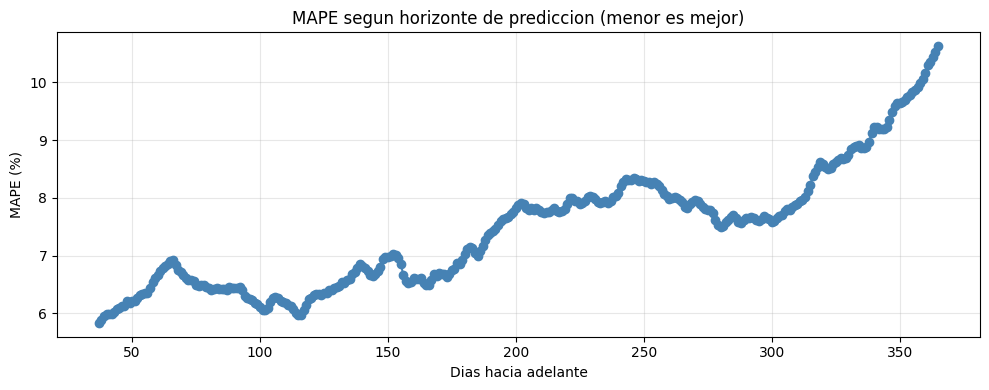

In [10]:
# ── Grafico: MAPE por horizonte de prediccion ──
# Muestra como aumenta el error a medida que predecimos mas lejos en el tiempo

mape_por_horizonte = df_metricas[['horizon', 'mape']].copy()
mape_por_horizonte['dias'] = mape_por_horizonte['horizon'].dt.days
mape_por_horizonte['MAPE (%)'] = mape_por_horizonte['mape'] * 100

plt.figure(figsize=(10, 4))
plt.plot(mape_por_horizonte['dias'], mape_por_horizonte['MAPE (%)'], marker='o', color='steelblue')
plt.title('MAPE segun horizonte de prediccion (menor es mejor)')
plt.xlabel('Dias hacia adelante')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ── Calculo manual de metricas (para entender como se calculan) ──
# Convertimos ds a datetime en ambos DataFrames antes de hacer el merge
df_hist = df.copy()
df_hist['ds'] = pd.to_datetime(df_hist['ds'])

df_eval = prediccion[['ds', 'yhat']].merge(df_hist, on='ds')

mae  = np.mean(np.abs(df_eval['y'] - df_eval['yhat']))
rmse = np.sqrt(np.mean((df_eval['y'] - df_eval['yhat'])**2))
mape = np.mean(np.abs((df_eval['y'] - df_eval['yhat']) / df_eval['y'])) * 100

print('=== Metricas sobre datos de entrenamiento ===')
print(f'  MAE  (Error Absoluto Medio)      : {mae:.4f}')
print(f'  RMSE (Raiz del Error Cuadratico) : {rmse:.4f}')
print(f'  MAPE (Error Porcentual Medio)    : {mape:.2f}%')
print()
if mape < 10:
    print('  MAPE < 10% -> desempeno EXCELENTE')
elif mape < 20:
    print('  MAPE 10-20% -> buen desempeno')
else:
    print('  MAPE > 20% -> revisar el modelo')

=== Metricas sobre datos de entrenamiento ===
  MAE  (Error Absoluto Medio)      : 0.3357
  RMSE (Raiz del Error Cuadratico) : 0.4837
  MAPE (Error Porcentual Medio)    : 4.00%

  MAPE < 10% -> desempeno EXCELENTE


### 8.3 Ventajas de Prophet

| # | Ventaja | Por que importa |
|---|---|---|
| 1 | **Facil de usar** | Pocas lineas de codigo para obtener predicciones profesionales |
| 2 | **Completamente automatico** | Detecta tendencias y estacionalidades sin configuracion manual |
| 3 | **Maneja datos faltantes** | No se rompe si faltan dias en los datos |
| 4 | **Robusto a outliers** | Valores atipicos no arruinan el modelo |
| 5 | **Multiples estacionalidades** | Anual, semanal y diaria al mismo tiempo |
| 6 | **Incorpora conocimiento de negocio** | Se pueden agregar festivos y eventos especiales |
| 7 | **Intervalos de incertidumbre** | Dice no solo el valor sino el rango probable |
| 8 | **Interpretable** | La descomposicion muestra el por que de la prediccion |
| 9 | **Gratuito y open source** | Disponible en Python y R, mantenido por Meta |
| 10 | **Escalable** | Funciona bien con datos diarios, semanales o mensuales |

### 8.4 Desventajas de Prophet

| # | Desventaja | Detalle |
|---|---|---|
| 1 | **Solo una variable a la vez** | No relaciona multiples variables automaticamente |
| 2 | **No modela autocorrelacion** | No considera que el valor de hoy depende del de ayer (ARIMA si lo hace) |
| 3 | **Necesita suficiente historia** | Con pocos datos no detecta bien las estacionalidades |
| 4 | **El error crece con el horizonte** | Predice bien a corto plazo; a largo plazo la incertidumbre aumenta |
| 5 | **Puede sobreajustarse** | Si los parametros estan mal configurados, sigue el ruido en lugar del patron |
| 6 | **Sin variables externas nativas** | No incorpora directamente clima, precio del dolar, etc. |
| 7 | **Instalacion compleja** | Requiere dependencias como pystan que a veces causan problemas |

### 8.5 Cuando usar Prophet y cuando no?

| Situacion | Usar Prophet? | Alternativa |
|---|---|---|
| Datos con estacionalidad clara | SI | - |
| Festivos o eventos especiales importan | SI | - |
| Quiero algo rapido e interpretable | SI | - |
| Alta dependencia entre dias consecutivos | Parcialmente | ARIMA / SARIMA |
| Necesito variables externas (precio, clima) | NO | XGBoost, LightGBM |
| Datos de alta frecuencia (minutos, segundos) | NO | LSTM |
| Serie de tiempo muy corta | NO | Modelos mas simples |


---
**Referencias:**
- https://facebook.github.io/prophet/docs/quick_start.html
- https://machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/
- https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.forecasting.fbprophet.Prophet.html